In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

In [3]:
# Load final matrix
data = pd.read_parquet('../data/processed/final_training_matrix.parquet')

In [4]:
# Select Features 
features = [col for col in data.columns if col not in ['user_id', 'product_id', 'target']]
X = data[features]
y = data['target']

In [ ]:
# User-Based Split 
unique_users = data['user_id'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

X_train = X[data['user_id'].isin(train_users)]
y_train = y[data['user_id'].isin(train_users)]
X_test = X[data['user_id'].isin(test_users)]
y_test = y[data['user_id'].isin(test_users)]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 10627766 | Test size: 2680187


In [6]:
# Initialize and Train
# use 'is_unbalance=True' because only ~10% of items are reordered
model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=100,
    learning_rate=0.1,
    is_unbalance=True, 
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='binary_logloss')

[LightGBM] [Info] Number of positive: 663178, number of negative: 9964588
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.457509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1628
[LightGBM] [Info] Number of data points in the train set: 10627766, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.062401 -> initscore=-2.709749
[LightGBM] [Info] Start training from score -2.709749


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


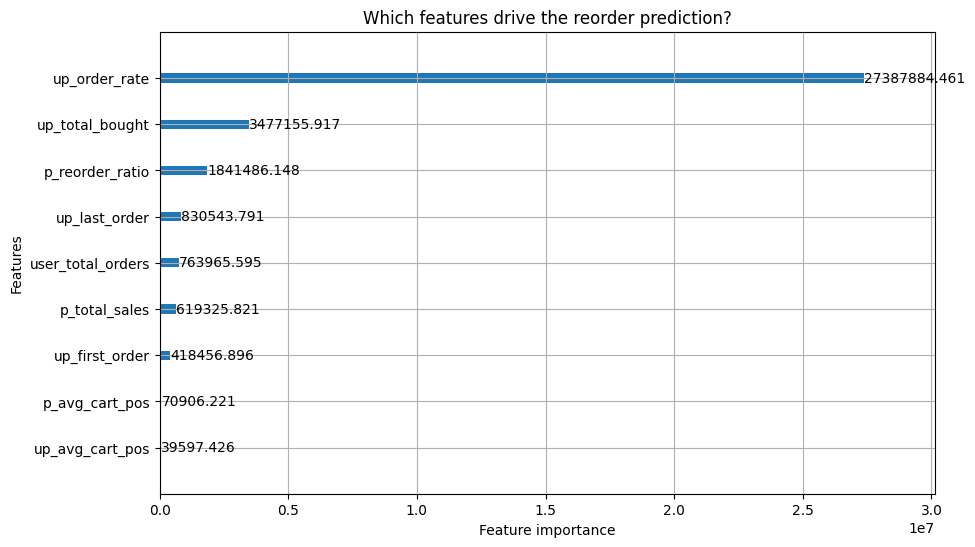

In [ ]:
# Plot Feature Importance
lgb.plot_importance(model, max_num_features=10, importance_type='gain', figsize=(10,6))
plt.title("Which features drive the reorder prediction?")
plt.show()

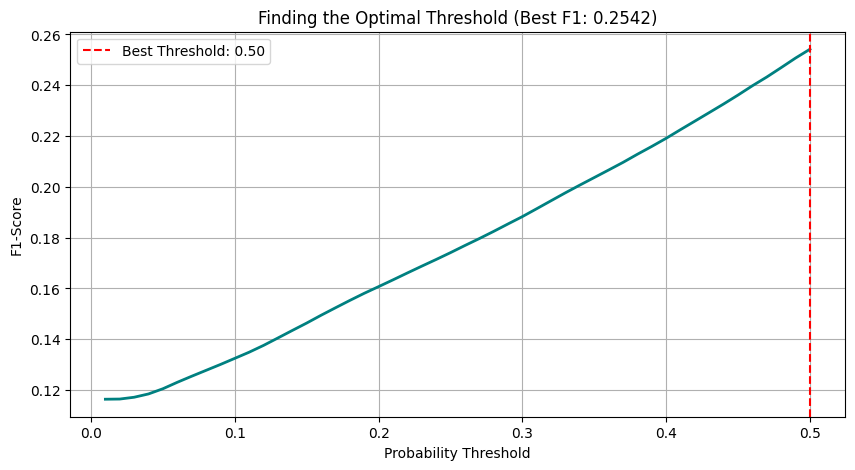

The optimal threshold for your model is: 0.50


In [ ]:
# Get the raw probabilities instead of 0/1 predictions
y_probs = model.predict_proba(X_test)[:, 1]

# Test a range of thresholds
thresholds = np.linspace(0.01, 0.50, 50)
f1_scores = []

for t in thresholds:
    y_pred_adj = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_adj))

# Find best one
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

# Visualize Optimization Curve
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color='teal', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.title(f"Finding the Optimal Threshold (Best F1: {best_f1:.4f})")
plt.xlabel("Probability Threshold")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True)
plt.show()

print(f"The optimal threshold for your model is: {best_threshold:.2f}")

In [9]:
# Calculate how many items per user pass the 0.50 threshold
y_pred_05 = (y_probs >= 0.50).astype(int)
print(f"Total recommendations at 0.50: {sum(y_pred_05)}")
print(f"Avg items per user: {sum(y_pred_05) / len(test_users):.2f}")

Total recommendations at 0.50: 810744
Avg items per user: 19.66


In [ ]:
import joblib

# Create models folder if it doesn't exist
import os
if not os.path.exists('../models'):
    os.makedirs('../models')

# Save the LightGBM model
joblib.dump(model, '../models/lgbm_reorder_model.pkl')

# Save your threshold so the recommender knows what to use
with open('../models/metadata.txt', 'w') as f:
    f.write(f"best_threshold: {best_threshold}")

print("Model and Metadata saved to /models/")

Model and Metadata saved to /models/
